# **Section 1 : Setting Up the Libraries and tools**



This section installs the extra libraries needed for the project and imports the tools used for the analysis.

In [1]:
# Install the libraries needed for SMOTE, SHAP and the models
!pip install imbalanced-learn shap -q
!pip install scikit-learn==1.9.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 59.8 MB/s eta 0:00:00


In [2]:
# Import tools for handling and visualising the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# Import the machine learning and preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [4]:
# Connect Google Drive so the dataset can be loaded
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import joblib

# **Section 2: Loading the Data**

In [6]:
# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Notebooks/CRP/Telco_customer_churn.csv")
print(f"Rows: {df.shape[0]} Columns:{df.shape[1]}")

Rows: 7043 Columns:33


# **Section 3: Exploring the Data (EDA)**

In [7]:
#Get all the Column Names
print("Column Names: ")
for c in df.columns:
  print(" ",c)

Column Names: 
  CustomerID
  Count
  Country
  State
  City
  Zip Code
  Lat Long
  Latitude
  Longitude
  Gender
  Senior Citizen
  Partner
  Dependents
  Tenure Months
  Phone Service
  Multiple Lines
  Internet Service
  Online Security
  Online Backup
  Device Protection
  Tech Support
  Streaming TV
  Streaming Movies
  Contract
  Paperless Billing
  Payment Method
  Monthly Charges
  Total Charges
  Churn Label
  Churn Value
  Churn Score
  CLTV
  Churn Reason


In [8]:
#Getting the first 5 rows
print("First 5 Rows: ")
df.head()

First 5 Rows: 


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [9]:
#Show the data types of each column
print("Data Types")
df.dtypes

Data Types


,0
CustomerID,object
Count,int64
Country,object
State,object
City,object
Zip Code,int64
Lat Long,object
Latitude,float64
Longitude,float64
Gender,object


In [10]:
#Summary Statistics for each columns
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


# **Section4: Checking and Fixing the Missing Values & Data Types**

In [11]:
#Check for the missing values
print("Missing Values: ")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing Values: 
Churn Reason    5174
dtype: int64


In [12]:
#Checking the datatype
df["Total Charges"].dtype

dtype('O')

In [13]:
#Converting the Total Charges to numeric & fill blanks with median
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"] = df["Total Charges"].fillna(df["Total Charges"].median())

# **Section 5: Creating A Target Variable**

In [14]:
if "Churn Value" in df.columns:
    df["target"] = df["Churn Value"]

print("Churn distribution:")
print(df["target"].value_counts())
print((df["target"].value_counts(normalize=True) * 100).round(1).astype(str) + " %")

Churn distribution:
target
0    5174
1    1869
Name: count, dtype: int64
target
0    73.5 %
1    26.5 %
Name: proportion, dtype: object


# **Section 6: Dropping the Churn (leakage Columns)**

In [15]:
#Listing all the columns to drop
dropped_cols = [
    "CustomerID", "Count", "Country", "State", "City",
    "Zip Code", "Lat Long", "Latitude", "Longitude",
    "Churn Label", "Churn Value",
    "Churn Score", "Churn Category", "Customer Status",
    "Satisfaction Score", "CLTV", "Churn Reason",
]

#Keeping CLTV and Churn Reason for later
req_cols = {}
for col in ["CLTV", "Churn Reason"]:
    if col in df.columns:
        req_cols[col] = df[col].copy()
        print(f"Saved '{col}' for later.")

to_drop = [c for c in dropped_cols if c in df.columns]
X = df.drop(columns=to_drop + ["target"])
y = df["target"]
print(f"Dropped {len(to_drop)} columns. Features remaining: {X.shape[1]}")

Saved 'CLTV' for later.
Saved 'Churn Reason' for later.
Dropped 14 columns. Features remaining: 19


# **Section7 : Encoding Categorical Features**

In [16]:
# Convert categorical variables into numerical features
X = pd.get_dummies(X, drop_first=True)
print(f"After encoding: {X.shape[1]} features")

After encoding: 30 features


# **Section 8: Spliiting into Trainig and Testing Data**

In [17]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows   Test: {X_test.shape[0]} rows")

Train: 5634 rows   Test: 1409 rows


# **Section 9: Scalling the numbers**

In [18]:
# Scale the features using the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled")

Scaled


# **Section 10: Balancing the classes with Smote**

In [19]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
print("After SMOTE, training distribution:")
print(pd.Series(y_train_balanced).value_counts())

After SMOTE, training distribution:
target
0    4139
1    4139
Name: count, dtype: int64


# **Section 11: Creating EDA Charts**

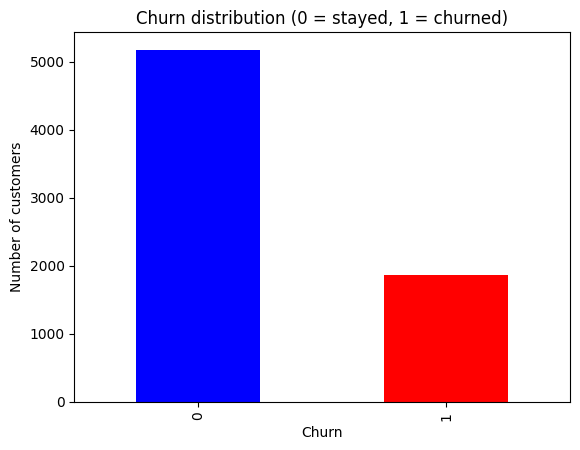

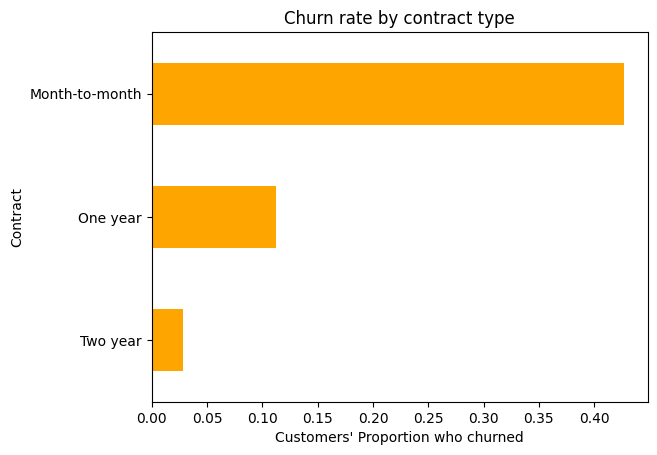

In [20]:
#Overall Churn Distribution Chart
df["target"].value_counts().plot(kind="bar", color=["blue", "red"])
plt.title("Churn distribution (0 = stayed, 1 = churned)")
plt.xlabel("Churn"); plt.ylabel("Number of customers")
plt.show()

#Churn rate by Contract Type
if "Contract" in df.columns:
    df.groupby("Contract")["target"].mean().sort_values().plot(
        kind="barh", color="orange")
    plt.title("Churn rate by contract type")
    plt.xlabel("Customers' Proportion who churned")
    plt.show()

# **Section 12: Final Check**

In [21]:
print("X_train_balanced:", X_train_balanced.shape)
print("y_train_balanced:", y_train_balanced.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_test:", y_test.shape)

X_train_balanced: (8278, 30)
y_train_balanced: (8278,)
X_test_scaled: (1409, 30)
y_test: (1409,)


# **Section 13A: Modelling Comparison**

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
import pandas as pd

#Define Models to compare
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state = 42),
    "Random Forest": RandomForestClassifier(random_state = 42),
}

results = []
for name, model in models.items():
  #Train model on the balanced data
  model.fit(X_train_balanced, y_train_balanced)

  #Make Predictions on the test dataset
  y_pred = model.predict(X_test_scaled)
  y_prob = model.predict_proba(X_test_scaled) [:,1]

  #Calcuate evaluation metrics
  results.append({
      "Model": name,
      "Accuracy": accuracy_score(y_test, y_pred),
      "Precision": precision_score(y_test, y_pred),
      "Recall": recall_score(y_test, y_pred),
      "F1": f1_score(y_test, y_pred),
      "ROC_AUC": roc_auc_score(y_test, y_prob)

  })

results_df = pd.DataFrame(results).round(3)
print(results_df)

                 Model  Accuracy  Precision  Recall     F1  ROC_AUC
0  Logistic Regression     0.745      0.513   0.775  0.618    0.848
1        Decision Tree     0.744      0.516   0.564  0.539    0.686
2        Random Forest     0.788      0.599   0.607  0.603    0.833


# **Section 13B: Cross-Validation of the Baseline Models**

In [23]:
#SMOTE before cross-validation instead of inside each fold
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

leaky_rows = []
for name, base_model in models.items():
    scores = cross_validate(base_model, X_train_balanced, y_train_balanced,
                            cv=cv, scoring=scoring, n_jobs=-1)
    leaky_rows.append({
        "Model": name,
        "Recall": scores["test_recall"].mean().round(3),
        "ROC_AUC": scores["test_roc_auc"].mean().round(3),
    })
print("SMOTE applied BEFORE cross-validation (incorrect):")
print(pd.DataFrame(leaky_rows).to_string(index=False))

SMOTE applied BEFORE cross-validation (incorrect):
              Model  Recall  ROC_AUC
Logistic Regression   0.822    0.869
      Decision Tree   0.798    0.799
      Random Forest   0.875    0.932


In [24]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import pandas as pd

# Use 5-fold stratified cross-validation so each fold has a similar churn ratio
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
}
# Use the original training data here
# SMOTE is applied inside the pipeline
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_rows = []
for name, base_model in models.items():
    pipe = ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", base_model),
    ])

    scores = cross_validate(pipe, X_train_scaled, y_train,
                            cv=cv, scoring=scoring, n_jobs=-1)

    cv_rows.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean().round(3),
        "Precision": scores["test_precision"].mean().round(3),
        "Recall": scores["test_recall"].mean().round(3),
        "F1": scores["test_f1"].mean().round(3),
        "ROC_AUC": scores["test_roc_auc"].mean().round(3),
        "Recall SD": scores["test_recall"].std().round(3),
    })

cv_results = pd.DataFrame(cv_rows)
print("5-fold cross-validated performance (SMOTE applied within each fold):")
print(cv_results)

5-fold cross-validated performance (SMOTE applied within each fold):
                 Model  Accuracy  Precision  Recall     F1  ROC_AUC  Recall SD
0  Logistic Regression     0.767      0.541   0.801  0.646    0.858      0.032
1        Decision Tree     0.723      0.480   0.553  0.514    0.669      0.017
2        Random Forest     0.787      0.598   0.602  0.600    0.840      0.025


# **Section 13C: Hyperparameter Tuning**

In [25]:
from sklearn.model_selection import GridSearchCV

# Use recall as the main scoring metric
# Apply SMOTE inside the pipeline to avoid data leakage
rf_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42)),
])

# Add the model name before each parameter in the search grid
rf_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [10, 20, None],
    "model__min_samples_leaf": [1, 5, 10],
    "model__class_weight": [None, "balanced"],
}

rf_search = GridSearchCV(rf_pipe, rf_grid, scoring="recall",
                         cv=cv, n_jobs=-1, verbose=1)
rf_search.fit(X_train_scaled, y_train)

print("Best Random Forest parameters:", rf_search.best_params_)
print(f"Best cross-validated recall: {rf_search.best_score_:.3f}")

lr_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=2000, random_state=42)),
])

lr_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"],
}

lr_search = GridSearchCV(lr_pipe, lr_grid, scoring="recall", cv=cv, n_jobs=-1)
lr_search.fit(X_train_scaled, y_train)

print("Best Logistic Regression parameters:", lr_search.best_params_)
print(f"Best cross-validated recall: {lr_search.best_score_:.3f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Random Forest parameters: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__n_estimators': 100}
Best cross-validated recall: 0.757
Best Logistic Regression parameters: {'model__C': 1, 'model__class_weight': None}
Best cross-validated recall: 0.801


In [26]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

tuned = {
    "Logistic Regression (tuned)": lr_search.best_estimator_.named_steps["model"],
    "Random Forest (tuned)": rf_search.best_estimator_.named_steps["model"],
}

final_rows = []
for name, model in tuned.items():
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    final_rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 3),
        "Precision": round(precision_score(y_test, preds), 3),
        "Recall": round(recall_score(y_test, preds), 3),
        "F1": round(f1_score(y_test, preds), 3),
        "ROC_AUC": round(roc_auc_score(y_test, probs), 3),
    })

final_results = pd.DataFrame(final_rows)
print("Tuned models on the held-out test set:")
print(final_results)

# Select the model with the highest recall
best_name = final_results.sort_values("Recall", ascending=False).iloc[0]["Model"]
best_model = tuned[best_name]
print(f"\nSelected model: {best_name}")

Tuned models on the held-out test set:
                         Model  Accuracy  Precision  Recall     F1  ROC_AUC
0  Logistic Regression (tuned)     0.745      0.513   0.775  0.618    0.848
1        Random Forest (tuned)     0.766      0.542   0.754  0.631    0.853

Selected model: Logistic Regression (tuned)


# **Section 14: Confusion Matrix & Classification Report**

Evaluating: Logistic Regression (tuned)


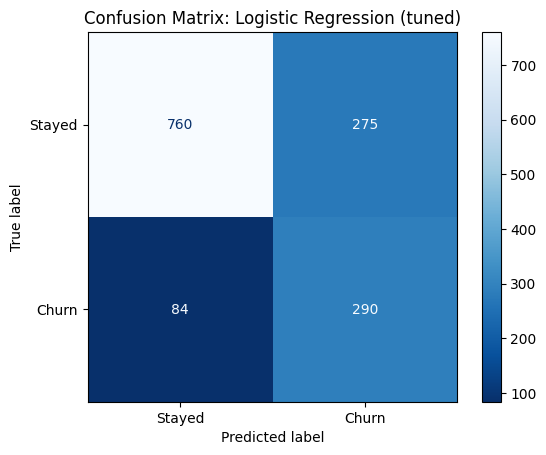


 Detailed Report:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409



In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# best_model was selected in Section 13c
print(f"Evaluating: {best_name}")

#make predictions with test dataset
preds = best_model.predict(X_test_scaled)

#Display confusion matrix
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test_scaled, y_test,
    display_labels = ["Stayed", "Churn"], cmap ="Blues_r"
)
plt.title(f"Confusion Matrix: {best_name}")
plt.show()

print("\n Detailed Report:")
print(classification_report(y_test, preds))

# **Section 15A: SHAP Analysis**

In [28]:
import shap

# Use the selected model and prepare the test data for SHAP
feature_names = list(X.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

print(f"Model ready for SHAP: {best_name}")

Model ready for SHAP: Logistic Regression (tuned)


In [29]:
import numpy as np

# Use the appropriate SHAP explainer for the selected model
if "Forest" in best_name or "Tree" in best_name:
    explainer = shap.TreeExplainer(best_model)
else:
    masker = shap.maskers.Independent(X_train_scaled,
                                      max_samples=X_train_scaled.shape[0])
    explainer = shap.LinearExplainer(best_model, masker)

shap_values = explainer.shap_values(X_test_df)

# Keep the SHAP values for the churn class
shap_values = np.array(shap_values)
if shap_values.ndim == 3:
  shap_values = shap_values [:, :, 1]

print("SHAP values calculated. Shape: ", shap_values.shape)


SHAP values calculated. Shape:  (1409, 30)


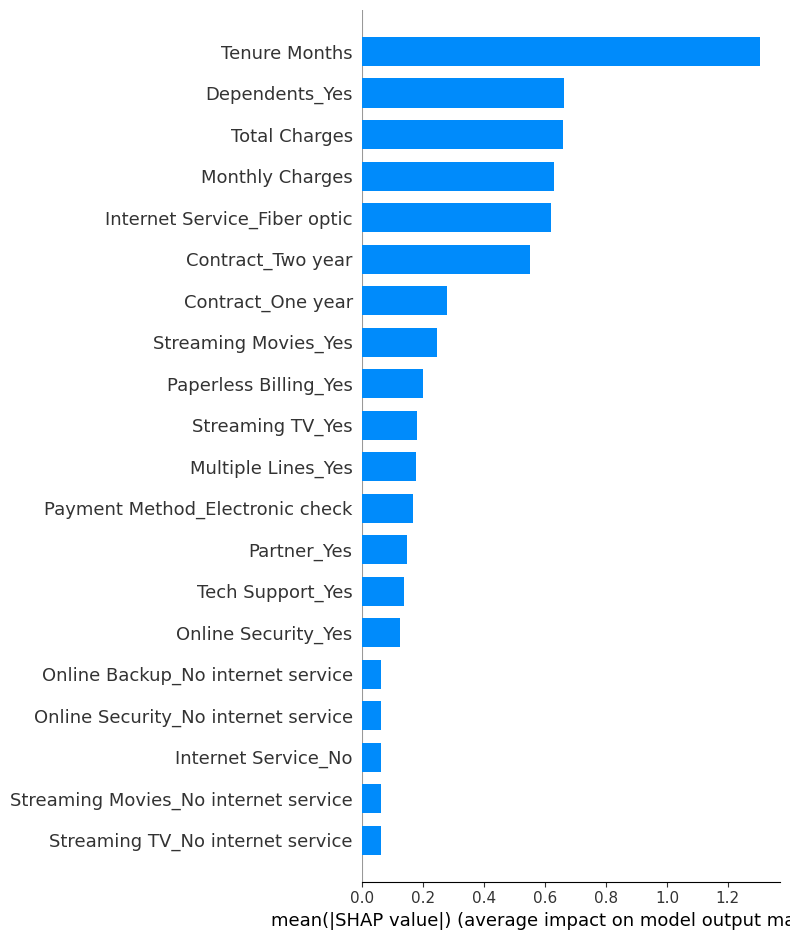

In [30]:
#top churn drivers ranked by the features
shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=True)

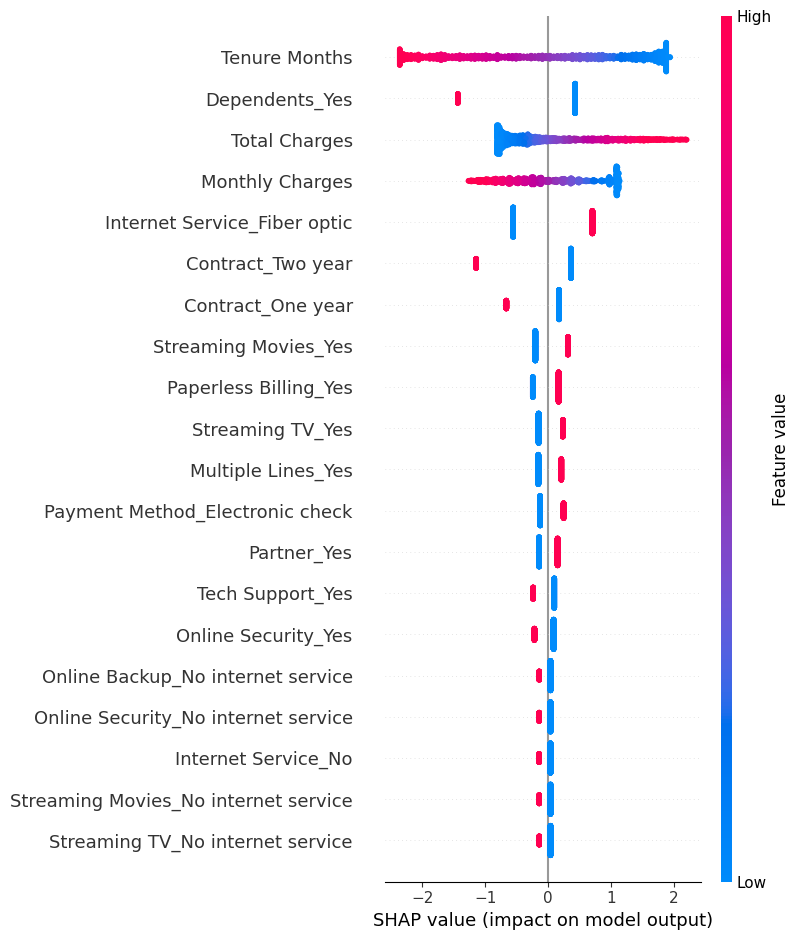

In [31]:
#show directions of each feature
shap.summary_plot(shap_values, X_test_df, show=True)

# **Section 15B: Comparing SHAP Results with Recorded Churn Reasons**

In [32]:
# Show the features that have the biggest impact on the model
mean_impact = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
print("Top 10 churn drivers according to SHAP:")
print(mean_impact.sort_values(ascending=False).head(10))

# Show the reasons recorded for customers who churned
reasons = df.loc[X_test.index, "Churn Reason"].dropna()
print(f"\nRecorded reasons available for {len(reasons)} of the "
      f"{(y_test == 1).sum()} churners in the test set")
print("\nTop 10 recorded reasons:")
print(reasons.value_counts().head(10))

Top 10 churn drivers according to SHAP:
Tenure Months                   1.306054
Dependents_Yes                  0.662512
Total Charges                   0.659179
Monthly Charges                 0.630445
Internet Service_Fiber optic    0.619158
Contract_Two year               0.548621
Contract_One year               0.278542
Streaming Movies_Yes            0.245176
Paperless Billing_Yes           0.198285
Streaming TV_Yes                0.180423
dtype: float64

Recorded reasons available for 374 of the 374 churners in the test set

Top 10 recorded reasons:
Churn Reason
Attitude of support person                   46
Competitor offered higher download speeds    38
Don't know                                   35
Competitor had better devices                33
Competitor offered more data                 33
Competitor made better offer                 26
Price too high                               25
Attitude of service provider                 23
Service dissatisfaction                 

# **Section 16A: Baseline CLTV Analysis (default threshold = 0.5)**

In [33]:
#get the CLTV values for customers in test data only
cltv_test = df.loc [X_test.index, "CLTV"].reset_index(drop=True)

#get the model predictions on the test data
y_pred = best_model.predict(X_test_scaled)

#put actual churn and predicted churn and CLTV in one table
results = pd.DataFrame({
    "actual": y_test.reset_index(drop= True),
    "predicted": y_pred,
    "CLTV": cltv_test
})

print(results.head())

   actual  predicted  CLTV
0       0          0  4842
1       0          1  5157
2       0          0  2894
3       0          1  2831
4       0          0  4324


In [34]:
#focus on customers who actually churned
actual_churners = results[results["actual"]==1]

#split them into the model caught vs missed
caught = actual_churners[actual_churners["predicted"]==1]
missed = actual_churners[actual_churners["predicted"]==0]

#add the customer lifetime value (CLTV) in each one
total_at_risk = actual_churners["CLTV"].sum()
value_caught = caught["CLTV"].sum()
value_missed = missed["CLTV"].sum()

print(f"Total CLTV at risk:{total_at_risk:,.0f}")
print(f"CLTV caught by model: {value_caught:,.0f}({value_caught/total_at_risk*100:.1f}%)")
print(f"CLTV missed by model: {value_missed:,.0f}({value_missed/total_at_risk*100:.1f}%)")


Total CLTV at risk:1,527,920
CLTV caught by model: 1,158,782(75.8%)
CLTV missed by model: 369,138(24.2%)


In [35]:
#compare the avg value of churners the model caught vs missed
print(f"Average CLTV of caught churners:{caught['CLTV'].mean():,.0f}")
print(f"Average CLTV of missed churners:{missed['CLTV'].mean():,.0f}")

Average CLTV of caught churners:3,996
Average CLTV of missed churners:4,394


# **Section 16B: Business Threshold Scenario (fixed threshold)**

In [36]:
# The threshold is derived from the mean CLTV of the training set under stated business assumptions.
from sklearn.metrics import recall_score, precision_score, confusion_matrix

probs = best_model.predict_proba(X_test_scaled)[:, 1]
actual = y_test.reset_index(drop=True).values
cltv_vals = df.loc[X_test.index, "CLTV"].reset_index(drop=True).values


SUCCESS_RATE = 0.30
OFFER_COST = 500

# Use the training data to calculate the reference CLTV
# The test data is kept separate from the threshold calculation

train_cltv_mean = df.loc[X_train.index, "CLTV"].mean()
BEST_THRESHOLD = OFFER_COST / (train_cltv_mean * SUCCESS_RATE)

print(f"Training-set mean CLTV: {train_cltv_mean:,.0f}")
print(f"Business-derived decision threshold: {BEST_THRESHOLD:.3f}")

pred_fixed = (probs >= BEST_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(actual, pred_fixed).ravel()

caught_fixed = (pred_fixed == 1) & (actual == 1)
net = (cltv_vals[caught_fixed] * SUCCESS_RATE).sum() - pred_fixed.sum() * OFFER_COST

print(f"Deployed fixed threshold: {BEST_THRESHOLD:.3f}")
print(f"Recall:    {recall_score(actual, pred_fixed):.3f}")
print(f"Precision: {precision_score(actual, pred_fixed):.3f}")
print(f"Flagged:   {pred_fixed.sum()} of {len(actual)} "
      f"({pred_fixed.sum()/len(actual):.1%} of the customer base)")
print(f"Churners caught: {tp} of {tp+fn}   False alarms: {fp}")
print(f"Net value: {net:,.0f}")

Training-set mean CLTV: 4,404
Business-derived decision threshold: 0.378
Deployed fixed threshold: 0.378
Recall:    0.866
Precision: 0.476
Flagged:   680 of 1409 (48.3% of the customer base)
Churners caught: 324 of 374   False alarms: 356
Net value: 53,732


In [37]:
# Compare the CLTV captured at the business threshold with the default threshold
caught_t = (pred_fixed == 1) & (actual == 1)
missed_t = (pred_fixed == 0) & (actual == 1)

total_at_risk = cltv_vals[actual == 1].sum()
print(f"\nAt the deployed threshold of {BEST_THRESHOLD:.3f}:")
print(f"CLTV caught:  {cltv_vals[caught_t].sum():,.0f} "
      f"({cltv_vals[caught_t].sum()/total_at_risk*100:.1f}%)")
print(f"CLTV missed:  {cltv_vals[missed_t].sum():,.0f} "
      f"({cltv_vals[missed_t].sum()/total_at_risk*100:.1f}%)")
print(f"Average CLTV of caught churners: {cltv_vals[caught_t].mean():,.0f}")
print(f"Average CLTV of missed churners: {cltv_vals[missed_t].mean():,.0f}")


At the deployed threshold of 0.378:
CLTV caught:  1,312,439 (85.9%)
CLTV missed:  215,481 (14.1%)
Average CLTV of caught churners: 4,051
Average CLTV of missed churners: 4,310


# **Section 16C: Sensitivity Analysis of the Business Assumptions**

In [38]:
# The same threshold calculation is used for each scenario

rows = []
for success_rate in (0.20, 0.30, 0.50):
    for offer_cost in (50, 100, 250, 500):
        t = offer_cost / (train_cltv_mean * success_rate)
        pred = (probs >= t).astype(int)

        caught = (pred == 1) & (actual == 1)
        net_s = (cltv_vals[caught] * success_rate).sum() - pred.sum() * offer_cost

        rows.append({
            "Success rate": success_rate,
            "Offer cost": offer_cost,
            "Threshold": round(t, 3),
            "Recall": round(recall_score(actual, pred, zero_division=0), 3),
            "Precision": round(precision_score(actual, pred, zero_division=0), 3),
            "Flagged": int(pred.sum()),
            "Flagged %": f"{pred.sum()/len(actual):.0%}",
            "Net value": int(net_s),
        })

sensitivity = pd.DataFrame(rows)
print(sensitivity.to_string(index=False))
print(f"\nDeployed configuration (Section 16B) is the row at "
      f"success rate {SUCCESS_RATE}, offer cost {OFFER_COST}.")

 Success rate  Offer cost  Threshold  Recall  Precision  Flagged Flagged %  Net value
          0.2          50      0.057   0.992      0.336     1103       78%     247640
          0.2         100      0.114   0.984      0.373      987       70%     201294
          0.2         250      0.284   0.904      0.438      772       55%      81449
          0.2         500      0.568   0.738      0.538      513       36%     -36999
          0.3          50      0.038   0.995      0.317     1173       83%     396378
          0.3         100      0.076   0.989      0.351     1053       75%     348080
          0.3         250      0.189   0.968      0.408      888       63%     219781
          0.3         500      0.378   0.866      0.476      680       48%      53731
          0.5          50      0.023   0.997      0.303     1231       87%     699678
          0.5         100      0.045   0.992      0.325     1141       81%     642875
          0.5         250      0.114   0.984      0.37

In [39]:
# Save the full-precision threshold
joblib.dump(BEST_THRESHOLD, "threshold.pkl")
print(f"Saved threshold: {BEST_THRESHOLD:.3f} "
      f"(offer cost {OFFER_COST}, success rate {SUCCESS_RATE:.0%})")
print("Verified, threshold.pkl contains:", round(joblib.load("threshold.pkl"), 3))

Saved threshold: 0.378 (offer cost 500, success rate 30%)
Verified, threshold.pkl contains: 0.378


In [40]:
# Check that the sensitivity analysis gives the same result as Section 16B
deployed_row = sensitivity[(sensitivity["Success rate"] == SUCCESS_RATE) &
                           (sensitivity["Offer cost"] == OFFER_COST)].iloc[0]
assert deployed_row["Net value"] == int(net), (
    f"16C net value {deployed_row['Net value']} does not match 16B {int(net)}")
assert deployed_row["Flagged"] == int(pred_fixed.sum()), "Flagged counts disagree"
print(f"\nConsistency check passed: Section 16C row "
      f"({SUCCESS_RATE:.0%}, {OFFER_COST}) reproduces Section 16B exactly.")


Consistency check passed: Section 16C row (30%, 500) reproduces Section 16B exactly.


# **Section 17: Saving the trained model**

In [41]:
# Save the training data used as the SHAP background
joblib.dump(X_train_scaled, "shap_background.pkl")
print("Saved: shap_background.pkl", X_train_scaled.shape)

Saved: shap_background.pkl (5634, 30)


In [42]:
import joblib

#save the trained model, the sclaer and the feature names
joblib.dump(best_model, "churn_model.pkl")
print(f"Saved model: {best_name}")


joblib.dump(scaler,"scaler.pkl")
joblib.dump(list(X.columns),"feature_names.pkl")

print("Saved : churn_model.pkl,scaler.pkl,feature_names.pkl")

Saved model: Logistic Regression (tuned)
Saved : churn_model.pkl,scaler.pkl,feature_names.pkl


# **Section 18: System Testing of the Deployed Application**

In [43]:
# Load the same preprocessing file used by the application
# The repository is private, so the file is uploaded to the Colab session

from google.colab import files
import sys, importlib, os

files.upload()   #select churn_features.py

sys.path.insert(0, "/content")
if "churn_features" in sys.modules:
    importlib.reload(sys.modules["churn_features"])
from churn_features import build_features, inputs_from_record, FORM_OPTIONS

print("import OK,", len(FORM_OPTIONS), "form fields")

Saving churn_features.py to churn_features.py
import OK, 16 form fields


In [44]:
# Run system tests to check that the application uses the same
# preprocessing and prediction process as the notebook.
test_log = []

def record(tid, description, expected, actual):
    test_log.append({"Test ID": tid, "Description": description,
                     "Expected": expected, "Actual": actual,
                     "Result": "PASS" if expected == actual else "FAIL"})


# TC01: feature list integrity
record("TC01", "Saved feature list has 30 features in training order",
       True, list(feature_names) == list(X.columns) and len(feature_names) == 30)

# TC02: column order preserved by the shared builder
sample = df.loc[X_test.index[0]]
record("TC02", "Shared module returns columns in the trained order",
       True, list(build_features(inputs_from_record(sample),
                                 feature_names).columns) == list(feature_names))

# TC03-TC07: Check the application encoding using different customer types
probe_idx = []
for cond in [df["Multiple Lines"] == "No phone service",
             df["Internet Service"] == "No",
             df["Contract"] == "Month-to-month",
             df["Contract"] == "One year",
             df["Contract"] == "Two year"]:
    hit = df.index[cond & df.index.isin(X_test.index)]
    if len(hit):
        probe_idx.append(hit[0])

for n, idx in enumerate(probe_idx, start=3):
    app_vals = build_features(inputs_from_record(df.loc[idx]),
                              feature_names).astype(float).values
    nb_vals = X.loc[[idx]].astype(float).values
    record(f"TC{n:02d}",
           f"App encoding matches notebook encoding "
           f"(customer {df.loc[idx, 'CustomerID']})",
           True, np.array_equal(app_vals, nb_vals))

# TC08: Check that the app and notebook give the same probability
idx = probe_idx[0]
app_input = build_features(inputs_from_record(df.loc[idx]), feature_names)
app_prob = best_model.predict_proba(scaler.transform(app_input))[0][1]
nb_prob = best_model.predict_proba(scaler.transform(X.loc[[idx]]))[0][1]
record("TC08", "App path and notebook path give the same probability",
       True, abs(app_prob - nb_prob) < 1e-9)

# TC09: Check that the saved threshold matches the analysis
loaded_threshold = joblib.load("threshold.pkl")
record("TC09", f"Saved threshold matches the reported value ({BEST_THRESHOLD:.3f})",
       True, loaded_threshold == BEST_THRESHOLD)

# TC10: Check that an incorrect feature name raises an error
mailed = df.index[(df["Payment Method"] == "Mailed check") &
                  df.index.isin(X_test.index)][0]
try:
    build_features(inputs_from_record(df.loc[mailed]),
                   [f for f in feature_names if f != "Payment Method_Mailed check"])
    guard = "not raised"
except KeyError:
    guard = "raised"
record("TC10", "Unknown feature name raises rather than being dropped",
       "raised", guard)

# TC11: Check the predictions for two contrasting customer profiles
high_inputs = dict(tenure=1, monthly_charges=100.0, total_charges=100.0,
                   gender="Male", senior="Yes", partner="No", dependents="No",
                   phone="Yes", multiple="No", internet="Fiber optic",
                   online_security="No", online_backup="No", device_protection="No",
                   tech_support="No", stream_tv="No", stream_movies="No",
                   contract="Month-to-month", paperless="Yes",
                   payment_method="Electronic check")
low_inputs = dict(tenure=70, monthly_charges=100.0, total_charges=7000.0,
                  gender="Male", senior="No", partner="Yes", dependents="Yes",
                  phone="Yes", multiple="Yes", internet="Fiber optic",
                  online_security="Yes", online_backup="Yes", device_protection="Yes",
                  tech_support="Yes", stream_tv="Yes", stream_movies="Yes",
                  contract="Two year", paperless="No",
                  payment_method="Bank transfer (automatic)")

p_high = best_model.predict_proba(
    scaler.transform(build_features(high_inputs, feature_names)))[0][1]
p_low = best_model.predict_proba(
    scaler.transform(build_features(low_inputs, feature_names)))[0][1]
record("TC11", f"High-risk profile scores above loyal profile "
               f"({p_high:.2f} vs {p_low:.2f})", True, p_high > p_low)

# TC12: Check that the saved threshold gives the expected number of predictions
record("TC12", f"Threshold {BEST_THRESHOLD:.3f} flags "
               f"{(probs >= BEST_THRESHOLD).sum()} of {len(probs)} test customers",
       True, int((probs >= BEST_THRESHOLD).sum()) == int(pred_fixed.sum()))


test_results = pd.DataFrame(test_log)
print(test_results.to_string(index=False))
n_pass = (test_results["Result"] == "PASS").sum()
print(f"\n{n_pass} of {len(test_results)} tests passed")

if n_pass < len(test_results):
    raise AssertionError("System tests failed. Do not deploy until resolved.")

Test ID                                                  Description Expected Actual Result
   TC01         Saved feature list has 30 features in training order     True   True   PASS
   TC02           Shared module returns columns in the trained order     True   True   PASS
   TC03 App encoding matches notebook encoding (customer 6317-YPKDH)     True   True   PASS
   TC04 App encoding matches notebook encoding (customer 1218-VKFPE)     True   True   PASS
   TC05 App encoding matches notebook encoding (customer 4190-MFLUW)     True   True   PASS
   TC06 App encoding matches notebook encoding (customer 4464-JCOLN)     True   True   PASS
   TC07 App encoding matches notebook encoding (customer 5236-PERKL)     True   True   PASS
   TC08         App path and notebook path give the same probability     True   True   PASS
   TC09           Saved threshold matches the reported value (0.378)     True   True   PASS
   TC10        Unknown feature name raises rather than being dropped   raised ra